# Hardness Dataset — Final EDA + Training Notebook (v2, with derived spec features)

Changes vs the previous version:
- Adds **Feature Set D**: non-LLM, regex/structure-derived features extracted from
  `hardness_spec_derived_features.csv` (spec section flags, work item counts, uncertainty
  markers, touch counts, topic-timing gaps, etc.)
- Adds **Feature Set E**: blueprint-level (24h cutoff) snapshot features from
  `hardness_blueprint_snapshot_features_24h.csv` (same early-activity signals as the
  topic-level snapshot, but aggregated per blueprint across all its topics)
- **Fixes an ordering bug**: `df_completed` (used for the `is_slow` target) was previously
  copied from `df` *before* the LaunchPad/spec feature engineering ran, so Feature Sets B and C
  were silently missing those columns for `is_slow` (they'd get dropped by
  `train_and_evaluate`'s `avail = [c for c in feature_cols if c in data.columns]` check).
  This is very likely why `is_slow` looked flat across feature sets before. Feature engineering
  now runs before the `is_slow` split, so all feature sets are actually complete for every task.
- Feature-set comparison plots and feature-importance coloring are now driven dynamically off
  `FEATURE_SETS`, so adding more sets later doesn't require editing the plotting code.

Expected files in the same folder as this notebook:
`hardness_dataset.csv`, `hardness_history_features.csv`,
`hardness_snapshot_features_{cutoff}h.csv` (one or more),
`hardness_spec_derived_features.csv` (new, non-LLM derived features)


In [45]:
import warnings
warnings.filterwarnings('ignore')

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
RANDOM_STATE = 42

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed (pip install xgboost) - will be skipped in model comparison.')

DATA_DIR = '.'  # change if your CSVs live elsewhere

print('Setup complete.')


Setup complete.


## 1. Load data

In [46]:
df   = pd.read_csv(f'{DATA_DIR}/hardness_dataset_updated.csv')

# History features are blueprint-level in this dataset (hardness_blueprint_history_features.csv,
# keyed by 'blueprint_id' = 'project::blueprint'), not topic-level -- fall back to the
# topic-level filename too, in case a future export provides one.
hist_path_bp = f'{DATA_DIR}/hardness_blueprint_history_features.csv'
hist_path_topic = f'{DATA_DIR}/hardness_history_features.csv'
if os.path.exists(hist_path_bp):
    hist = pd.read_csv(hist_path_bp)
    HIST_KEY = 'blueprint_id'
elif os.path.exists(hist_path_topic):
    hist = pd.read_csv(hist_path_topic)
    HIST_KEY = 'topic_id'
else:
    raise FileNotFoundError(
        f'Neither {hist_path_bp} nor {hist_path_topic} found -- history features are required.'
    )

# Look for snapshot files (both topic-level and blueprint-level)
snapshot_files = sorted(
    glob.glob(f'{DATA_DIR}/hardness_blueprint_snapshot_features_*h.csv') +
    glob.glob(f'{DATA_DIR}/hardness_snapshot_features_*h.csv')
)
snapshots = {}
for f in snapshot_files:
    m = re.search(r'(\d+)h\.csv', f)
    if m:
        snapshots[int(m.group(1))] = pd.read_csv(f)

df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
df['bp_join_key'] = df['project'].astype(str) + '::' + df['blueprint'].astype(str)

print(f'Main dataset : {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'History      : {hist.shape[0]:,} rows x {hist.shape[1]} cols')
print(f'Snapshots found: {sorted(snapshots.keys())} hour cutoffs')
DEFAULT_CUTOFF = min(snapshots.keys()) if snapshots else None
print(f'Using cutoff: {DEFAULT_CUTOFF}h (change DEFAULT_CUTOFF below if you want a different one)')


Main dataset : 1,548 rows x 56 cols
History      : 1,606 rows x 6 cols
Snapshots found: [24, 48, 72, 168] hour cutoffs
Using cutoff: 24h (change DEFAULT_CUTOFF below if you want a different one)


In [47]:
# New: non-LLM derived spec features (from extract_spec_features.py run over hardness_inputs.jsonl)
spec_derived_path = f'{DATA_DIR}/hardness_spec_derived_features.csv'
HAS_SPEC_DERIVED = os.path.exists(spec_derived_path)

if HAS_SPEC_DERIVED:
    spec_derived = pd.read_csv(spec_derived_path)
    print(f'Spec-derived : {spec_derived.shape[0]:,} rows x {spec_derived.shape[1]} cols')

    # df uses 'blueprint' / 'project', spec_derived uses 'blueprint_name' / 'lp_project'
    # -- same content, different column names, confirmed by sample-value inspection.
    spec_derived_renamed = spec_derived.rename(
        columns={'blueprint_name': 'blueprint', 'lp_project': 'project'}
    )
    merge_keys = [c for c in ['blueprint', 'project'] if c in df.columns and c in spec_derived_renamed.columns]

    if not merge_keys:
        print('WARNING: still no shared key after renaming. Check column names on both sides.')
        HAS_SPEC_DERIVED = False
    else:
        before_cols = df.shape[1]
        before_rows = df.shape[0]
        df = df.merge(spec_derived_renamed, on=merge_keys, how='left', suffixes=('', '_derived'))
        print(f'Merged on {merge_keys}: {before_cols} -> {df.shape[1]} cols, '
              f'{before_rows} -> {df.shape[0]} rows (should be unchanged if keys are unique)')

        # Sanity check: how many rows actually got derived features attached vs went to NaN
        derived_sample_col = 'work_items_count'
        if derived_sample_col in df.columns:
            matched = df[derived_sample_col].notna().sum()
            print(f'Rows with derived features matched: {matched} / {len(df)} '
                  f'({matched / len(df) * 100:.1f}%)')
else:
    print(f'No {spec_derived_path} found -- Feature Set D will be skipped. '
          'Run extract_spec_features.py first if you want it.')

Spec-derived : 1,568 rows x 27 cols
Merged on ['blueprint', 'project']: 56 -> 81 cols, 1548 -> 1548 rows (should be unchanged if keys are unique)
Rows with derived features matched: 1548 / 1548 (100.0%)


### 1b. Blueprint-level snapshot features (24h cutoff)


In [48]:
# New: blueprint-level snapshot features (24h cutoff) from
# hardness_blueprint_snapshot_features_24h.csv. Same early-activity signals as the
# topic-level `snapshots` dict loaded above (early_comment_count, early_patchset_count, etc.),
# but aggregated per blueprint across every topic linked to it -- useful for blueprints with
# multiple topics, where a single topic's snapshot understates overall early activity.
bp_snapshot_path = f'{DATA_DIR}/hardness_blueprint_snapshot_features_24h.csv'
HAS_BP_SNAPSHOT = os.path.exists(bp_snapshot_path)

if HAS_BP_SNAPSHOT:
    bp_snapshot = pd.read_csv(bp_snapshot_path)
    print(f'Blueprint snapshot (24h): {bp_snapshot.shape[0]:,} rows x {bp_snapshot.shape[1]} cols')

    # bp_snapshot is keyed by 'blueprint_id' formatted as 'project::blueprint' -- build the
    # same composite key on df (confirmed by sample-value inspection: e.g.
    # 'aodh::composite-threshold-rule-alarm').
    df['bp_join_key'] = df['project'].astype(str) + '::' + df['blueprint'].astype(str)

    # Column names collide with the topic-level SNAPSHOT_COLS above (same feature
    # definitions at a different granularity) -- suffix them so both sets stay distinguishable
    # after merging.
    cols_to_suffix = [c for c in bp_snapshot.columns if c not in ('blueprint_id', 'cutoff_hours')]
    bp_snapshot_renamed = bp_snapshot.rename(
        columns={c: f'{c}_bp24' for c in cols_to_suffix}
    ).drop(columns=['cutoff_hours'])

    before_cols = df.shape[1]
    before_rows = df.shape[0]
    df = df.merge(bp_snapshot_renamed, left_on='bp_join_key', right_on='blueprint_id', how='left')
    df = df.drop(columns=['blueprint_id', 'bp_join_key'])
    print(f'Merged on project::blueprint -> blueprint_id: {before_cols} -> {df.shape[1]} cols, '
          f'{before_rows} -> {df.shape[0]} rows (should be unchanged if keys are unique)')

    bp_snapshot_sample_col = 'initial_change_count_bp24'
    if bp_snapshot_sample_col in df.columns:
        matched = df[bp_snapshot_sample_col].notna().sum()
        print(f'Rows with blueprint-level snapshot matched: {matched} / {len(df)} '
              f'({matched / len(df) * 100:.1f}%)')
else:
    print(f'No {bp_snapshot_path} found -- Feature Set E will be skipped.')


Blueprint snapshot (24h): 1,606 rows x 13 cols
Merged on project::blueprint -> blueprint_id: 81 -> 91 cols, 1548 -> 1548 rows (should be unchanged if keys are unique)
Rows with blueprint-level snapshot matched: 1437 / 1548 (92.8%)


### 1c. LLM hardness scores (Feature Set F)


In [49]:
# New: LLM-based hardness/complexity scores from hardness_llm_scores.csv.
# Keyed the same way as the spec-derived file ('blueprint_name' / 'lp_project'),
# so we reuse the same rename + merge pattern as Feature Set D.
llm_scores_path = f'{DATA_DIR}/hardness_llm_scores2.csv'
HAS_LLM_SCORES = os.path.exists(llm_scores_path)

if HAS_LLM_SCORES:
    llm_scores = pd.read_csv(llm_scores_path)
    print(f'LLM scores   : {llm_scores.shape[0]:,} rows x {llm_scores.shape[1]} cols')

    # A few blueprints got scored twice (retried run) -- keep the last (most recent) scoring
    # per (blueprint_name, lp_project) and drop the rest before merging.
    n_dupe_keys = llm_scores.duplicated(subset=['blueprint_name', 'lp_project']).sum()
    if n_dupe_keys:
        print(f'Dropping {n_dupe_keys} duplicate-key rows (keeping last occurrence per blueprint/project)')
        llm_scores = llm_scores.drop_duplicates(subset=['blueprint_name', 'lp_project'], keep='last')

    # Rows where the LLM call itself failed (rate limit / 500s) have no scores at all --
    # drop them here rather than letting them silently become 0s or get imputed later.
    llm_scores = llm_scores[llm_scores['hardness_score'].notna()].copy()

    # Only keep the numeric score columns as features -- 'rationale' is free text (not a
    # model feature) and 'llm_error' is bookkeeping, already used above to filter failures.
    LLM_SCORE_COLS_RAW = [
        'section_problem_description_score', 'section_proposed_change_score',
        'section_alternatives_score', 'section_data_model_score', 'section_rest_api_score',
        'section_security_impact_score', 'section_testing_score', 'section_dependencies_score',
        'section_documentation_impact_score', 'section_work_items_score',
        'hardness_score', 'complexity', 'ambiguity', 'risk',
    ]
    llm_scores_renamed = llm_scores.rename(
        columns={'blueprint_name': 'blueprint', 'lp_project': 'project'}
    )[['blueprint', 'project'] + LLM_SCORE_COLS_RAW].rename(
        columns={c: f'llm_{c}' for c in LLM_SCORE_COLS_RAW}
    )

    merge_keys = [c for c in ['blueprint', 'project'] if c in df.columns and c in llm_scores_renamed.columns]

    if not merge_keys:
        print('WARNING: no shared key with hardness_llm_scores.csv. Check column names.')
        HAS_LLM_SCORES = False
    else:
        before_cols = df.shape[1]
        before_rows = df.shape[0]
        df = df.merge(llm_scores_renamed, on=merge_keys, how='left', suffixes=('', '_llm'))
        print(f'Merged on {merge_keys}: {before_cols} -> {df.shape[1]} cols, '
              f'{before_rows} -> {df.shape[0]} rows (should be unchanged if keys are unique)')

        llm_sample_col = 'llm_hardness_score'
        if llm_sample_col in df.columns:
            matched = df[llm_sample_col].notna().sum()
            print(f'Rows with LLM scores matched: {matched} / {len(df)} '
                  f'({matched / len(df) * 100:.1f}%)')
else:
    print(f'No {llm_scores_path} found -- Feature Set F will be skipped.')


LLM scores   : 1,567 rows x 18 cols
Dropping 7 duplicate-key rows (keeping last occurrence per blueprint/project)
Merged on ['blueprint', 'project']: 91 -> 105 cols, 1548 -> 1548 rows (should be unchanged if keys are unique)
Rows with LLM scores matched: 1479 / 1548 (95.5%)


## 2. Shape, dtypes, missingness

In [50]:
print(df.dtypes.value_counts())
print()
miss = df.isna().mean().sort_values(ascending=False) * 100
miss = miss[miss > 0]
print(f'Columns with missing values: {len(miss)} / {df.shape[1]}')
print(miss.round(1).to_string())


float64                39
int64                  35
object                 18
bool                   12
datetime64[ns, UTC]     1
Name: count, dtype: int64

Columns with missing values: 33 / 105
days_topic_to_bp_creation                 100.0
ci_failure_rate                            84.2
early_human_comment_ratio_bp24             63.8
early_comment_velocity_bp24                63.6
first_review_delay_hours_censored_bp24     63.6
summary_word_count                         41.3
spec_word_count                            41.3
has_full_spec                              41.3
initial_change_count_bp24                   7.2
n_repos_at_cutoff_bp24                      7.2
n_branches_at_cutoff_bp24                   7.2
reviewed_within_cutoff_bp24                 7.2
early_unique_reviewers_bp24                 7.2
early_patchset_count_bp24                   7.2
early_comment_count_bp24                    7.2
n_topics_at_cutoff_bp24                     7.2
llm_section_proposed_change_score    

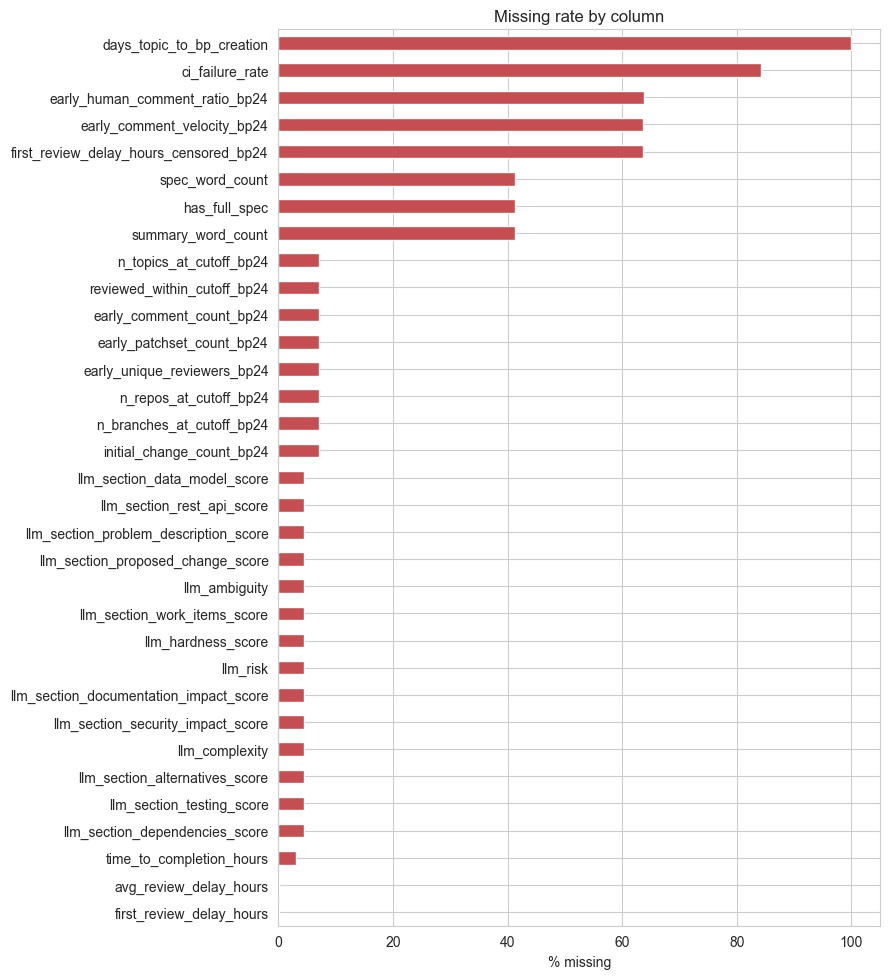

In [51]:
plt.figure(figsize=(9, max(4, len(miss) * 0.3)))
miss.sort_values().plot(kind='barh', color='#C44E52')
plt.xlabel('% missing')
plt.title('Missing rate by column')
plt.tight_layout()
plt.show()


## 3. Leakage / near-duplicate feature detection

In [52]:
numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols_all].corr().abs()
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if pd.notna(r) and r > 0.98:
            pairs.append((cols[i], cols[j], round(r, 4)))
pairs_df = pd.DataFrame(pairs, columns=['feature_1', 'feature_2', 'correlation']).sort_values(
    'correlation', ascending=False)
print(f'{len(pairs_df)} near-duplicate pairs found (|corr| > 0.98):')
pairs_df


18 near-duplicate pairs found (|corr| > 0.98):


,feature_1,feature_2,correlation
17,early_comment_count_bp24,early_comment_velocity_bp24,1.0000
5,total_revisions,total_patchsets,1.0000
14,people_involved_count,author_count,1.0000
11,ci_rerun_recheck_msgs,ci_retries,1.0000
2,n_changes,total_code_review_plus2,0.9992
0,n_changes,n_merged,0.9991
8,n_merged,total_code_review_plus2,0.9989
12,ci_runs,ci_successes,0.9981
7,n_reviewers,author_count,0.9973
6,n_reviewers,people_involved_count,0.9973


In [53]:
# Confirmed on the previous run of this dataset: these are exact or near-exact duplicates.
# Keeping one representative per cluster, dropping the rest before training.
# NOTE: re-check pairs_df above after adding the new derived features -- if any of the new
# columns show up here as near-duplicates of existing ones, add them to this list too.
LEAKY_COLS_TO_DROP = [
    'total_patchsets',          # dup of total_revisions (corr 1.0)
    'ci_rerun_recheck_msgs',    # dup of ci_retries (corr 1.0)
    'author_count',             # dup of people_involved_count (corr 1.0)
    'n_merged',                  # dup of n_changes (corr 0.999)
    'total_code_review_plus2',  # dup of n_changes / n_merged (corr 0.999)
    'ci_successes',              # dup of ci_runs (corr 0.998)
    'n_reviewers',                # dup of people_involved_count / author_count (corr 0.997)
    'total_code_review_minus2', # dup of n_abandoned / n_changes (corr ~0.98-0.99)
    'code_authors_count',        # dup of n_repos / people_involved_count / author_count (corr ~0.98)
]
dropped = [c for c in LEAKY_COLS_TO_DROP if c in df.columns]
df = df.drop(columns=dropped)
print(f'Dropped {len(dropped)} leaky columns: {dropped}')


Dropped 9 leaky columns: ['total_patchsets', 'ci_rerun_recheck_msgs', 'author_count', 'n_merged', 'total_code_review_plus2', 'ci_successes', 'n_reviewers', 'total_code_review_minus2', 'code_authors_count']


## 4. Feature engineering + feature sets

Moved ahead of target/`df_completed` creation (previously section 4, now section 5) so that
`df_completed` inherits every engineered column, including the new Feature Set D columns.
Previously `df_completed` was copied from `df` *before* this ran, silently starving the
`is_slow` task of Sets B/C/D.

**Leakage fix (this version):** `total_topic_changes`, `topic_creation_spread_days`, and
`n_distinct_projects_touched` removed from `SPEC_DERIVED_COLS`. Per advisor guidance, spec-file
churn (`avg_touch_count`/`max_touch_count`) is fair game, but topic-level activity volume/timing
spread aggregated across a blueprint's *entire* lifetime (including implementation) is not --
those three are effectively the same construct as the `excessive_rework`/`is_slow` targets
themselves. Outputs below from Section 8 onward need a fresh run to reflect this change.

In [54]:
priority_map = {'Essential': 4, 'High': 3, 'Medium': 2, 'Low': 1, 'Undefined': 0}
df['bp_priority_score']       = df['priority'].map(priority_map).fillna(0)
df['bp_is_approved']          = (df['definition_status'] == 'Approved').astype(int)
df['bp_is_complete']          = df['is_complete'].fillna(False).astype(int)
df['bp_has_goal']             = df['has_accepted_goal'].fillna(False).astype(int)
df['bp_has_full_spec']        = df['has_full_spec'].fillna(False).astype(int)
df['bp_spec_word_count']      = df['spec_word_count'].fillna(0)
df['bp_summary_word_count']   = df['summary_word_count'].fillna(0)


SNAPSHOT_COLS = [
    
]
# NOTE: hardness_blueprint_history_features.csv uses 'author_past_blueprint_count' /
# 'repo_historical_blueprint_count' (blueprint-level naming) instead of the
# 'author_past_topic_count' / 'repo_historical_topic_count' names this notebook originally
# expected. `hist` is only merged into each task's dataframe in section 6 (not into `df`
# here), so we list both variants and let train_and_evaluate()'s own
# `avail = [c for c in feature_cols if c in data.columns]` filter keep whichever exists.
HISTORY_COLS = [
    'author_past_topic_count', 'author_past_blueprint_count', 'author_past_merge_rate',
    'author_tenure_days', 'repo_historical_topic_count', 'repo_historical_blueprint_count',
    'repo_historical_abandon_rate',
]
LAUNCHPAD_COLS = ['bp_priority_score', 'bp_is_approved', 'bp_is_complete', 'bp_has_goal']
SPEC_COLS = ['bp_has_full_spec', 'bp_spec_word_count', 'bp_summary_word_count', 'bp_n_topics_urls']

# New: non-LLM derived features from hardness_spec_derived_features.csv
SPEC_DERIVED_COLS = [
    'has_section_problem_description', 'has_section_proposed_change',
    'has_section_alternatives', 'has_section_data_model', 'has_section_rest_api',
    'has_section_security_impact', 'has_section_testing', 'has_section_dependencies',
    'has_section_documentation_impact', 'work_items_count', 'codeblock_count',
    'uncertainty_marker_count', 'url_count', 'xref_count', 'image_count',
    'sentence_count', 'avg_sentence_len_words', 'avg_touch_count', 'max_touch_count',
    'days_topic_to_bp_creation', 'elaboration_ratio',
]
# Dropped as implementation-time leakage (per advisor guidance: spec-file touch_count is OK,
# but topic-level activity/timing spread during implementation is not):
#   - total_topic_changes           -- all-topic Gerrit activity count, same construct as
#                                       n_changes/total_revisions which define excessive_rework
#   - topic_creation_spread_days    -- elapsed time across topics, same construct as is_slow's
#                                       target (time_to_completion_days)
#   - n_distinct_projects_touched   -- aggregated over all topics/all time, same all-topic-
#                                       activity scope as the two above
# Kept: avg_touch_count / max_touch_count, since these are scoped to how many changes touched
# the same .rst spec file specifically -- a design-quality signal, not implementation volume.
# Only keep the ones that actually made it into df (in case the merge was skipped or
# some columns weren't computed)
SPEC_DERIVED_COLS = [c for c in SPEC_DERIVED_COLS if c in df.columns]

# New: blueprint-level (24h cutoff) snapshot features -- same signals as SNAPSHOT_COLS above,
# aggregated per-blueprint instead of per-topic (see section 1b).
BP_SNAPSHOT_COLS = [
    
]
BP_SNAPSHOT_COLS = [c for c in BP_SNAPSHOT_COLS if c in df.columns]

FEATURE_SETS = {
    'A_baseline':        SNAPSHOT_COLS + HISTORY_COLS,
    'B_plus_launchpad':  SNAPSHOT_COLS + HISTORY_COLS + LAUNCHPAD_COLS,
    'C_plus_spec_meta':  SNAPSHOT_COLS + HISTORY_COLS + LAUNCHPAD_COLS + SPEC_COLS,
}
if HAS_SPEC_DERIVED and SPEC_DERIVED_COLS:
    FEATURE_SETS['D_plus_spec_derived'] = (
        SNAPSHOT_COLS + HISTORY_COLS + LAUNCHPAD_COLS + SPEC_COLS + SPEC_DERIVED_COLS
    )
else:
    print('Skipping Feature Set D (no derived-features file merged in, or no columns matched).')

if HAS_BP_SNAPSHOT and BP_SNAPSHOT_COLS:
    # Build on the richest set available so far (D if present, else C) plus the new
    # blueprint-level snapshot columns.
    richest_cols = list(FEATURE_SETS.values())[-1]
    FEATURE_SETS['E_plus_bp_snapshot'] = richest_cols + BP_SNAPSHOT_COLS
else:
    print('Skipping Feature Set E (no blueprint-level snapshot file merged in, or no columns matched).')

# New: LLM hardness/complexity scores from hardness_llm_scores.csv (see section 1c).
LLM_SCORE_COLS = [
    'llm_section_problem_description_score', 'llm_section_proposed_change_score',
    'llm_section_alternatives_score', 'llm_section_data_model_score',
    'llm_section_rest_api_score', 'llm_section_security_impact_score',
    'llm_section_testing_score', 'llm_section_dependencies_score',
    'llm_section_documentation_impact_score', 'llm_section_work_items_score',
    'llm_hardness_score', 'llm_complexity', 'llm_ambiguity', 
]
LLM_SCORE_COLS = [c for c in LLM_SCORE_COLS if c in df.columns]

if HAS_LLM_SCORES and LLM_SCORE_COLS:
    # Build on the richest set available so far (E if present, else D/C) plus the new
    # LLM-derived scores.
    richest_cols = list(FEATURE_SETS.values())[-1]
    FEATURE_SETS['F_plus_llm_scores'] = richest_cols + LLM_SCORE_COLS
else:
    print('Skipping Feature Set F (no LLM scores file merged in, or no columns matched).')

for name, cols in FEATURE_SETS.items():
    print(f'{name:22s}: {len(cols)} features')


Skipping Feature Set E (no blueprint-level snapshot file merged in, or no columns matched).
A_baseline            : 7 features
B_plus_launchpad      : 11 features
C_plus_spec_meta      : 15 features
D_plus_spec_derived   : 36 features
F_plus_llm_scores     : 49 features


## 5. Target variable definitions

In [55]:
# df_completed is now copied AFTER feature engineering above, so it carries every
# engineered column (bp_*, SPEC_DERIVED_COLS, etc.) -- this is the ordering fix.
df_completed = df[df['time_to_completion_hours'].notna()].copy()
df_completed['time_to_completion_days'] = df_completed['time_to_completion_hours'] / 24.0
P90_DAYS = df_completed['time_to_completion_days'].quantile(0.90)
df_completed['is_slow'] = (df_completed['time_to_completion_days'] >= P90_DAYS).astype(int)

df['at_risk'] = (~df['outcome'].astype(str).str.lower().isin(['merged'])).astype(int)

ci_p90 = df['ci_retries'].quantile(0.90)
rev_p90 = df['total_revisions'].quantile(0.90)
df['excessive_rework'] = (
    (df['ci_retries'].fillna(0) > ci_p90) | (df['total_revisions'].fillna(0) > rev_p90)
).astype(int)

# --- high_effort: messages-per-revision (discussion density), not raw message count ---
df['msgs_per_revision'] = df['total_messages'] / df['total_revisions'].replace(0, np.nan)
msg_per_rev_p90 = df['msgs_per_revision'].quantile(0.90)
df['high_effort'] = (df['msgs_per_revision'].fillna(0) > msg_per_rev_p90).astype(int)

TASKS = {'is_slow': df_completed, 'at_risk': df, 'excessive_rework': df, 'high_effort': df}

print(f'[is_slow]          n={len(df_completed):,}  P90={P90_DAYS:.1f}d  positive={df_completed["is_slow"].mean()*100:.2f}%')
print(f'[at_risk]          n={len(df):,}  positive={df["at_risk"].mean()*100:.2f}%')
print(f'[excessive_rework] n={len(df):,}  ci_p90={ci_p90:.1f} rev_p90={rev_p90:.1f}  positive={df["excessive_rework"].mean()*100:.2f}%')
print(f'[high_effort]      n={len(df):,}  msgs_per_rev_p90={msg_per_rev_p90:.2f}  positive={df["high_effort"].mean()*100:.2f}%')


[is_slow]          n=1,500  P90=435.2d  positive=10.00%
[at_risk]          n=1,548  positive=54.33%
[excessive_rework] n=1,548  ci_p90=756.3 rev_p90=451.6  positive=13.37%
[high_effort]      n=1,548  msgs_per_rev_p90=12.55  positive=10.01%


In [56]:
print('=== Overlap check: high_effort vs excessive_rework (should be low) ===')
print(pd.crosstab(df['high_effort'], df['excessive_rework']))
overlap_pct = ((df['high_effort'] == 1) & (df['excessive_rework'] == 1)).sum() / max(df['high_effort'].sum(), 1) * 100
print(f'\n{overlap_pct:.1f}% of high_effort positives are also excessive_rework positives')


=== Overlap check: high_effort vs excessive_rework (should be low) ===
excessive_rework     0    1
high_effort                
0                 1215  178
1                  126   29

18.7% of high_effort positives are also excessive_rework positives


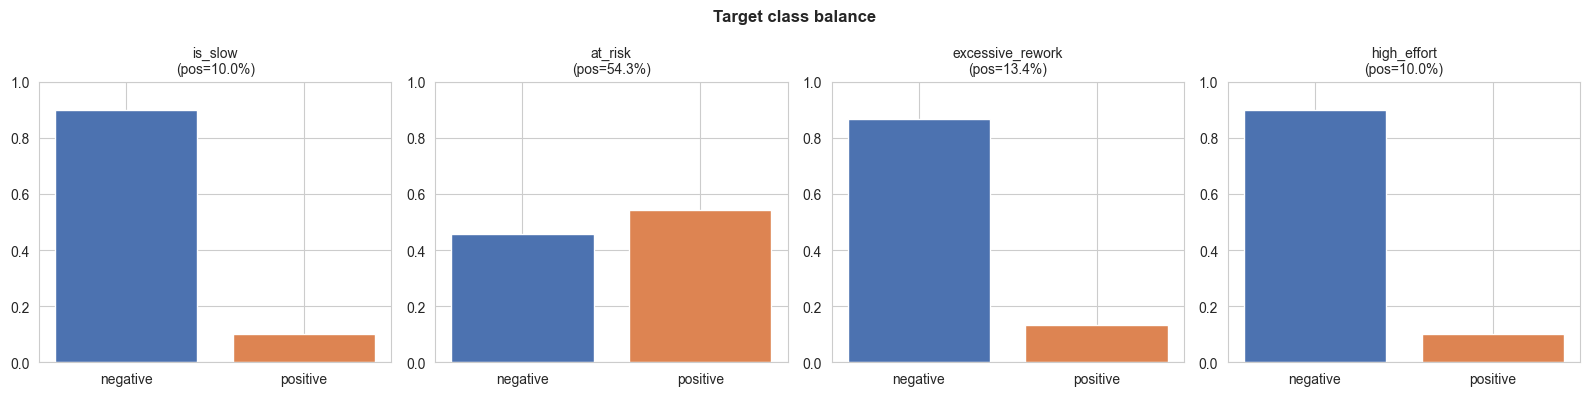

In [57]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
rates = {
    'is_slow': df_completed['is_slow'].mean(), 'at_risk': df['at_risk'].mean(),
    'excessive_rework': df['excessive_rework'].mean(), 'high_effort': df['high_effort'].mean(),
}
for ax, (name, rate) in zip(axes, rates.items()):
    ax.bar(['negative', 'positive'], [1 - rate, rate], color=['#4C72B0', '#DD8452'])
    ax.set_title(f'{name}\n(pos={rate*100:.1f}%)', fontsize=10)
    ax.set_ylim(0, 1)
plt.suptitle('Target class balance', fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Merge history + snapshot features per task

In [58]:
snap = snapshots.get(DEFAULT_CUTOFF)
if snap is None:
    raise FileNotFoundError("No snapshot file found. Check DATA_DIR / filenames.")

task_data = {}

for task, base_df in TASKS.items():
    if 'bp_join_key' not in base_df.columns:
        base_df['bp_join_key'] = base_df['project'].astype(str) + '::' + base_df['blueprint'].astype(str)
    # Merge history features first, using whichever key they were loaded with (blueprint_id or topic_id)
    if HIST_KEY == 'blueprint_id':
        merged = base_df.merge(hist, left_on='bp_join_key', right_on='blueprint_id', how='left', suffixes=('', '_hist'))
        if 'blueprint_id' in merged.columns:
            merged = merged.drop(columns=['blueprint_id'])
    else:
        merged = base_df.merge(hist, on='topic_id', how='left')

    # Then merge the early-activity snapshot, on topic_id if topic-level, else on blueprint_id
    if 'topic_id' in snap.columns:
        merged = merged.merge(snap, on='topic_id', how='left', suffixes=('', '_snap'))
    elif 'blueprint_id' in snap.columns:
        merged = merged.merge(snap, left_on='bp_join_key', right_on='blueprint_id', how='left', suffixes=('', '_snap'))
    task_data[task] = merged
    print(f'  [{task:16s}] merged: {len(merged):,} rows')


  [is_slow         ] merged: 1,500 rows
  [at_risk         ] merged: 1,548 rows
  [excessive_rework] merged: 1,548 rows
  [high_effort     ] merged: 1,548 rows


In [59]:
# Snapshot files loaded dynamically at notebook initialization
print(f'Available snapshot cutoffs: {sorted(snapshots.keys())} hours')
print(f'Active default cutoff: {DEFAULT_CUTOFF}h')


Available snapshot cutoffs: [24, 48, 72, 168] hours
Active default cutoff: 24h


## 7. Temporal train/test split + training function

In [60]:
def train_and_evaluate(data, feature_cols, target_col, date_col='created_at',
                       test_frac=0.25, model=None):
    avail = [c for c in feature_cols if c in data.columns]
    work = data.dropna(subset=[target_col]).copy()
    if date_col in work.columns and work[date_col].notna().any():
        work = work.sort_values(date_col)

    X = work[avail].fillna(0)
    y = work[target_col].astype(int)

    if y.nunique() < 2 or y.sum() < 5:
        print(f'  [SKIP] {target_col}: insufficient positives (n={len(work)}, pos={y.sum()})')
        return None

    split = int(len(work) * (1 - test_frac))
    X_train, X_test = X.iloc[:split], X.iloc[split:]
    y_train, y_test = y.iloc[:split], y.iloc[split:]

    if y_train.nunique() < 2 or y_test.nunique() < 2:
        print(f'  [SKIP] {target_col}: single class after temporal split')
        return None

    if model is None:
        model = RandomForestClassifier(
            n_estimators=300, max_depth=10, min_samples_leaf=5,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        )

    model.fit(X_train, y_train)
    y_prob = model.predict_proba(X_test)[:, 1]

    return {
        'n': len(work), 'n_train': len(X_train), 'n_test': len(X_test),
        'positive_rate': round(y.mean() * 100, 2),
        'auc': roc_auc_score(y_test, y_prob), 'ap': average_precision_score(y_test, y_prob),
        'model': model, 'feature_cols': avail,
    }

print('train_and_evaluate() ready.')


train_and_evaluate() ready.


## 8. Feature set comparison (A vs B vs C vs D)

In [61]:
BEST_FEATURE_SET = list(FEATURE_SETS.keys())[-1]  # always compare against the richest set available

comparison_rows = []
best_results = {}

for feat_name, feat_cols in FEATURE_SETS.items():
    for task, data in task_data.items():
        res = train_and_evaluate(data, feat_cols, task)
        if res is None:
            continue
        comparison_rows.append({'feature_set': feat_name, 'task': task, 'auc': res['auc'], 'ap': res['ap']})
        print(f'[{feat_name:22s}]  task={task:<18}  AUC={res["auc"]:.3f}  AP={res["ap"]:.3f}')
        if feat_name == BEST_FEATURE_SET:
            best_results[task] = res

comp_df = pd.DataFrame(comparison_rows)
pivot_auc = comp_df.pivot_table(index='feature_set', columns='task', values='auc')
print('\n=== ROC-AUC Comparison Table ===')
pivot_auc.round(3)


[A_baseline            ]  task=is_slow             AUC=0.633  AP=0.184
[A_baseline            ]  task=at_risk             AUC=0.614  AP=0.651
[A_baseline            ]  task=excessive_rework    AUC=0.802  AP=0.322
[A_baseline            ]  task=high_effort         AUC=0.677  AP=0.218
[B_plus_launchpad      ]  task=is_slow             AUC=0.666  AP=0.213
[B_plus_launchpad      ]  task=at_risk             AUC=0.622  AP=0.660
[B_plus_launchpad      ]  task=excessive_rework    AUC=0.814  AP=0.421
[B_plus_launchpad      ]  task=high_effort         AUC=0.737  AP=0.247
[C_plus_spec_meta      ]  task=is_slow             AUC=0.668  AP=0.259
[C_plus_spec_meta      ]  task=at_risk             AUC=0.619  AP=0.675
[C_plus_spec_meta      ]  task=excessive_rework    AUC=0.838  AP=0.496
[C_plus_spec_meta      ]  task=high_effort         AUC=0.711  AP=0.226
[D_plus_spec_derived   ]  task=is_slow             AUC=0.774  AP=0.363
[D_plus_spec_derived   ]  task=at_risk             AUC=0.682  AP=0.734
[D_plu

task,at_risk,excessive_rework,high_effort,is_slow
feature_set,,,,
A_baseline,0.614,0.802,0.677,0.633
B_plus_launchpad,0.622,0.814,0.737,0.666
C_plus_spec_meta,0.619,0.838,0.711,0.668
D_plus_spec_derived,0.682,0.856,0.731,0.774
F_plus_llm_scores,0.704,0.868,0.702,0.773


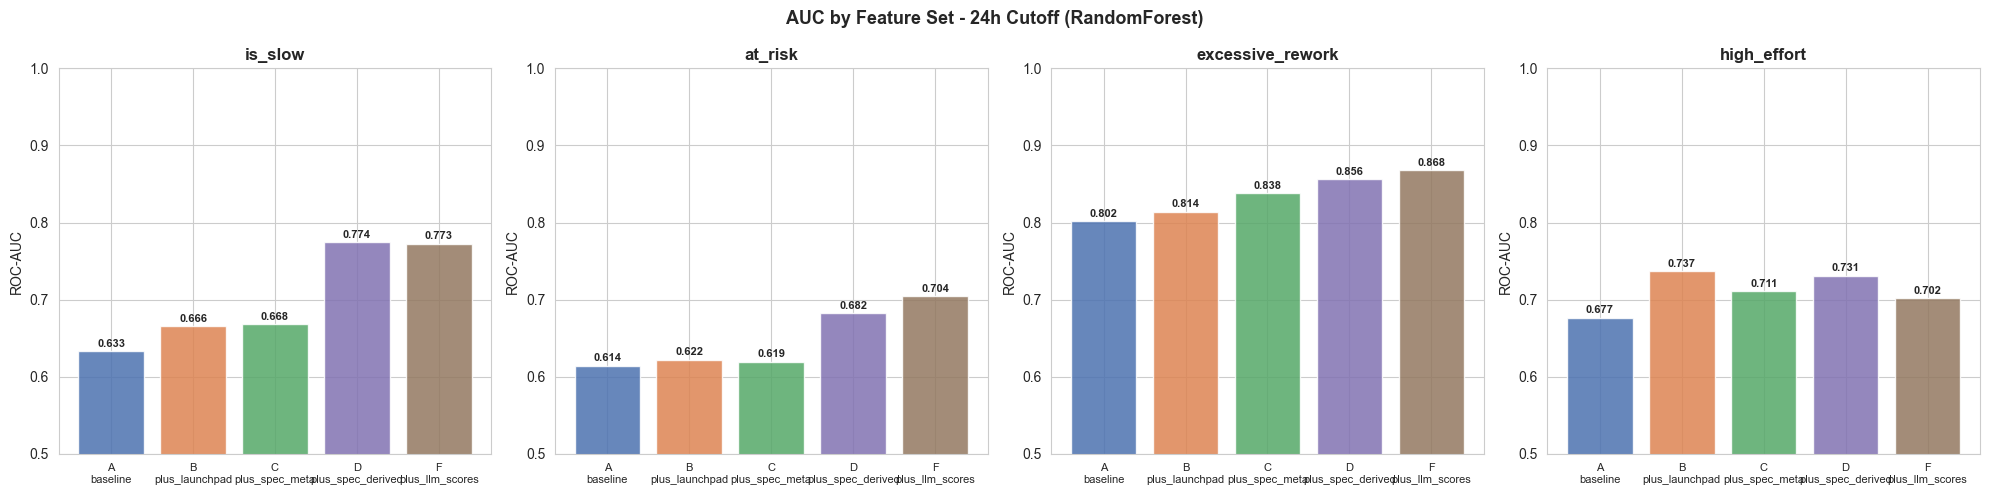

In [62]:
tasks = list(TASKS.keys())
palette = ['#4C72B0', '#DD8452', '#55A868', '#8172B2', '#937860']
colors = palette[:len(FEATURE_SETS)]
feat_labels = [k.replace('_', '\n', 1) for k in FEATURE_SETS]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, task in zip(axes, tasks):
    sub = comp_df[comp_df['task'] == task].set_index('feature_set')
    aucs = [sub.loc[k, 'auc'] if k in sub.index else 0 for k in FEATURE_SETS]
    bars = ax.bar(range(len(FEATURE_SETS)), aucs, color=colors, alpha=0.85, edgecolor='white')
    ax.set_xticks(range(len(FEATURE_SETS)))
    ax.set_xticklabels(feat_labels, fontsize=8)
    ax.set_ylim(0.5, 1.0)
    ax.set_title(task, fontweight='bold')
    ax.set_ylabel('ROC-AUC')
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2., h + 0.003, f'{h:.3f}',
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle(f'AUC by Feature Set - {DEFAULT_CUTOFF}h Cutoff (RandomForest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Model comparison: RandomForest vs LogisticRegression vs XGBoost

In [63]:
models = {
    'RandomForest': RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LogisticRegression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE))
    ])
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.05,
        eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1
    )

model_comp_rows = []
cols_best = FEATURE_SETS[BEST_FEATURE_SET]

for model_name, model_obj in models.items():
    for task, data in task_data.items():
        res = train_and_evaluate(data, cols_best, task, model=model_obj)
        if res is None:
            continue
        model_comp_rows.append({'model': model_name, 'task': task, 'auc': res['auc'], 'ap': res['ap']})

mcomp_df = pd.DataFrame(model_comp_rows)
pivot_models = mcomp_df.pivot_table(index='model', columns='task', values='auc')
print(f'=== Model Architecture AUC Comparison (Feature Set: {BEST_FEATURE_SET}) ===')
pivot_models.round(3)


=== Model Architecture AUC Comparison (Feature Set: F_plus_llm_scores) ===


task,at_risk,excessive_rework,high_effort,is_slow
model,,,,
LogisticRegression,0.683,0.855,0.731,0.672
RandomForest,0.704,0.868,0.702,0.773
XGBoost,0.731,0.856,0.677,0.751


## 10. Feature importance

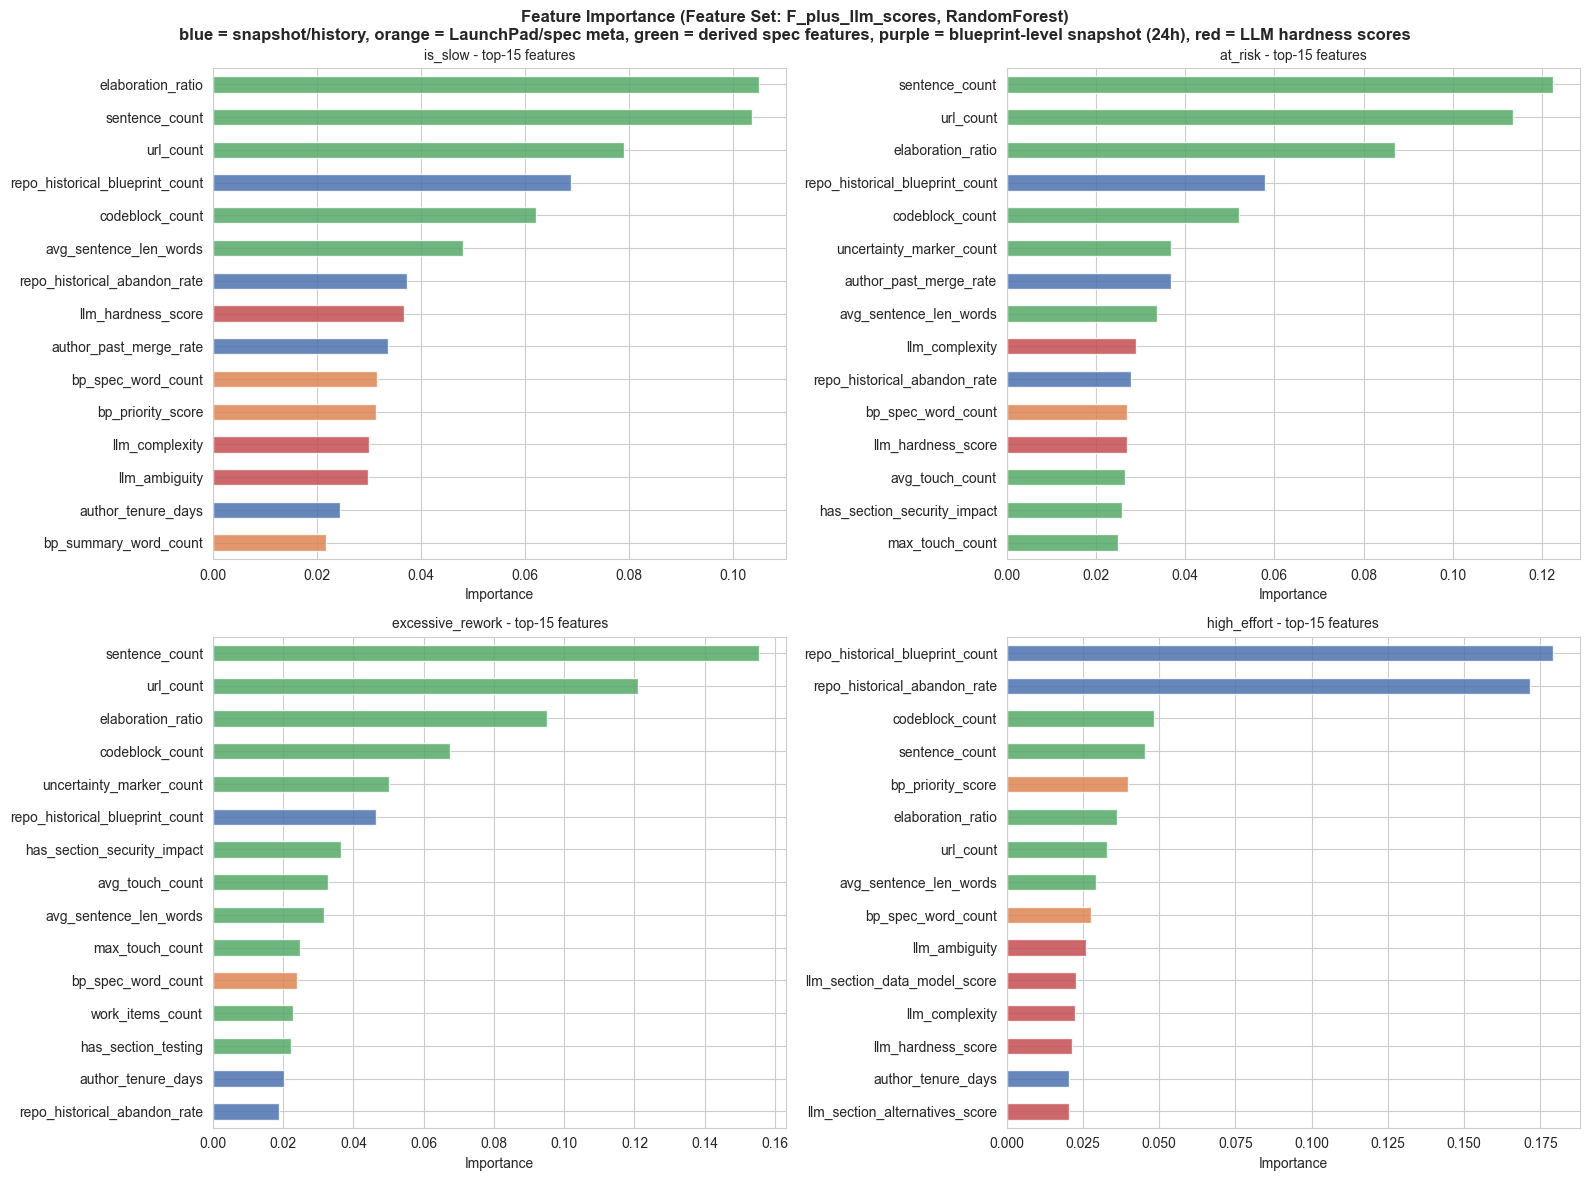

In [64]:
META_SET = set(LAUNCHPAD_COLS + SPEC_COLS)
DERIVED_SET = set(SPEC_DERIVED_COLS)
BP_SNAPSHOT_SET = set(BP_SNAPSHOT_COLS)
LLM_SET = set(LLM_SCORE_COLS)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for ax, task in zip(axes, tasks):
    if task not in best_results:
        ax.set_title(f'{task} - no result')
        continue
    res = best_results[task]
    importances = pd.Series(res['model'].feature_importances_, index=res['feature_cols'])
    top15 = importances.sort_values(ascending=False).head(15)

    def color_for(f):
        if f in LLM_SET:
            return '#C44E52'   # red = LLM hardness/complexity scores
        if f in BP_SNAPSHOT_SET:
            return '#8172B2'   # purple = blueprint-level snapshot (24h)
        if f in DERIVED_SET:
            return '#55A868'   # green = new non-LLM derived features
        if f in META_SET:
            return '#DD8452'   # orange = LaunchPad/spec meta
        return '#4C72B0'       # blue = baseline snapshot/history

    colors_imp = [color_for(f) for f in top15.index]
    top15.sort_values().plot(kind='barh', ax=ax, color=colors_imp[::-1], alpha=0.85)
    ax.set_title(f'{task} - top-15 features', fontsize=10)
    ax.set_xlabel('Importance')

plt.suptitle(f'Feature Importance (Feature Set: {BEST_FEATURE_SET}, RandomForest)\n'
             'blue = snapshot/history, orange = LaunchPad/spec meta, green = derived spec features, '
             'purple = blueprint-level snapshot (24h), red = LLM hardness scores',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Early-warning cutoff sweep (only runs if you have multiple snapshot files)

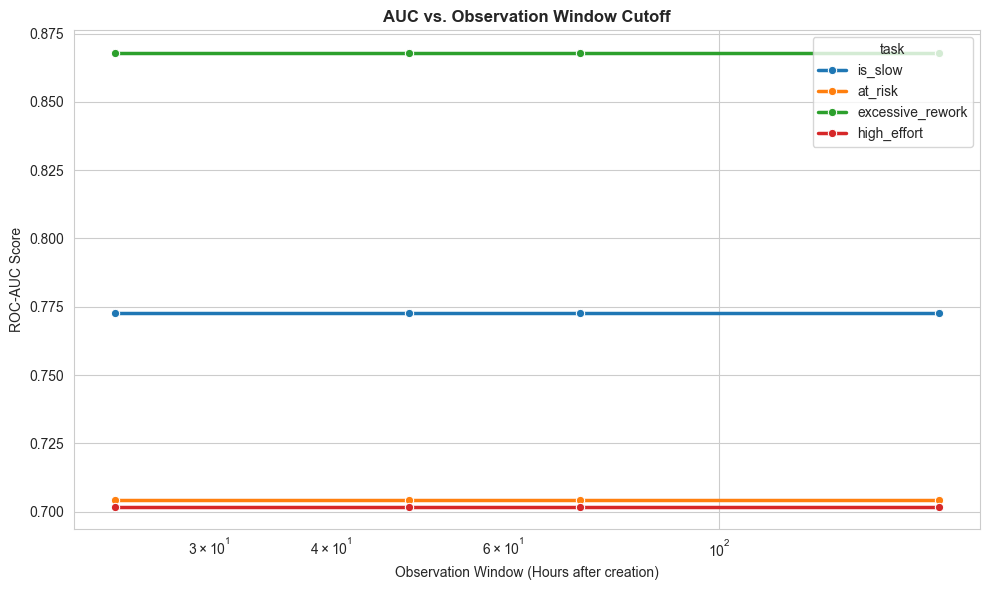

In [65]:
sweep_rows = []
for c, c_snap in sorted(snapshots.items()):
    for task, base_df in TASKS.items():
        if 'bp_join_key' not in base_df.columns:
            base_df['bp_join_key'] = base_df['project'].astype(str) + '::' + base_df['blueprint'].astype(str)
        if HIST_KEY == 'blueprint_id':
            merged = base_df.merge(hist, left_on='bp_join_key', right_on='blueprint_id', how='left', suffixes=('', '_hist'))
            if 'blueprint_id' in merged.columns:
                merged = merged.drop(columns=['blueprint_id'])
        else:
            merged = base_df.merge(hist, on='topic_id', how='left')

        if 'topic_id' in c_snap.columns:
            merged = merged.merge(c_snap, on='topic_id', how='left', suffixes=('', '_snap'))
        elif 'blueprint_id' in c_snap.columns:
            merged = merged.merge(c_snap, left_on='bp_join_key', right_on='blueprint_id', how='left', suffixes=('', '_snap'))
        res = train_and_evaluate(merged, cols_best, task)
        if res is not None:
            sweep_rows.append({'cutoff_hours': c, 'task': task, 'auc': res['auc'], 'ap': res['ap']})

sweep_df = pd.DataFrame(sweep_rows)
if sweep_df['cutoff_hours'].nunique() > 1:
    plt.figure(figsize=(10, 6))
    sns.lineplot(data=sweep_df, x='cutoff_hours', y='auc', hue='task', marker='o', linewidth=2.5)
    plt.xscale('log')
    plt.xlabel('Observation Window (Hours after creation)')
    plt.ylabel('ROC-AUC Score')
    plt.title('AUC vs. Observation Window Cutoff', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print(f'Only one snapshot cutoff available ({list(snapshots.keys())}h).')
    sweep_df


## 12. Summary

- Leaky columns dropped: 9 confirmed near-duplicate features (see section 3) -- re-check this
  list once the derived features are in, in case any of them turn out to correlate too closely
  with existing columns.
- `high_effort` defined as messages-per-revision (discussion density), not raw message count.
- **Ordering bug fixed**: feature engineering now runs before `df_completed` is created, so
  `is_slow` now actually receives Feature Sets B, C, and D instead of silently falling back to
  Set A. Compare the new `is_slow` AUCs against the old notebook's flat results.
- **Feature Set D** (non-LLM derived: spec section flags, work item counts, uncertainty markers,
  touch counts, topic-timing gaps, elaboration ratio) is included automatically if
  `hardness_spec_derived_features.csv` is present in `DATA_DIR`.
- **Feature Set E** (blueprint-level, 24h-cutoff snapshot features from
  `hardness_blueprint_snapshot_features_24h.csv`) is included automatically on top of the
  richest set otherwise available. Joined on the composite `project::blueprint` key against
  `blueprint_id`; columns are suffixed `_bp24` to avoid colliding with the topic-level
  snapshot columns from section 1.
- Still open: junk-topic filtering in `process_blueprint` (upstream in the scraper, not this
  notebook), blueprint_id/topic_id linkage for any future feature files, LLM hardness scorer
  (not used here by request -- everything in Set D is deterministic regex/structure parsing).


In [66]:
# Run this cell right after the "Target variable definitions" cell (Section 5).
# It reuses df, df_completed, P90_DAYS, ci_p90, rev_p90, msg_per_rev_p90 already
# defined there — no need to recompute anything.

class_balance_rows = [
    {
        'task': 'is\\_slow',
        'n': len(df_completed),
        'threshold': f'{P90_DAYS:.1f} days',
        'positive_rate': df_completed['is_slow'].mean() * 100,
    },
    {
        'task': 'at\\_risk',
        'n': len(df),
        'threshold': '--',
        'positive_rate': df['at_risk'].mean() * 100,
    },
    {
        'task': 'excessive\\_rework',
        'n': len(df),
        'threshold': f'ci>{ci_p90:.1f} or rev>{rev_p90:.1f}',
        'positive_rate': df['excessive_rework'].mean() * 100,
    },
    {
        'task': 'high\\_effort',
        'n': len(df),
        'threshold': f'msgs/rev>{msg_per_rev_p90:.2f}',
        'positive_rate': df['high_effort'].mean() * 100,
    },
]

print(f"{'Task':<20} {'n':>8} {'Threshold':>22} {'Positive rate':>15}")
for row in class_balance_rows:
    print(f"{row['task']:<20} {row['n']:>8,} {row['threshold']:>22} {row['positive_rate']:>14.2f}%")

print("\n--- LaTeX table rows (copy into tab:class-balance) ---\n")
for row in class_balance_rows:
    print(f"{row['task']:<18} & {row['n']:>6,} & {row['threshold']:<22} & {row['positive_rate']:.2f}\\% \\\\")

Task                        n              Threshold   Positive rate
is\_slow                1,500             435.2 days          10.00%
at\_risk                1,548                     --          54.33%
excessive\_rework       1,548  ci>756.3 or rev>451.6          13.37%
high\_effort            1,548         msgs/rev>12.55          10.01%

--- LaTeX table rows (copy into tab:class-balance) ---

is\_slow           &  1,500 & 435.2 days             & 10.00\% \\
at\_risk           &  1,548 & --                     & 54.33\% \\
excessive\_rework  &  1,548 & ci>756.3 or rev>451.6  & 13.37\% \\
high\_effort       &  1,548 & msgs/rev>12.55         & 10.01\% \\
